In [ ]:
# !pip install qmsolve

Took 190.30964541435242
STORE_STEPS: 801
Number of stored wavefunctions: 802


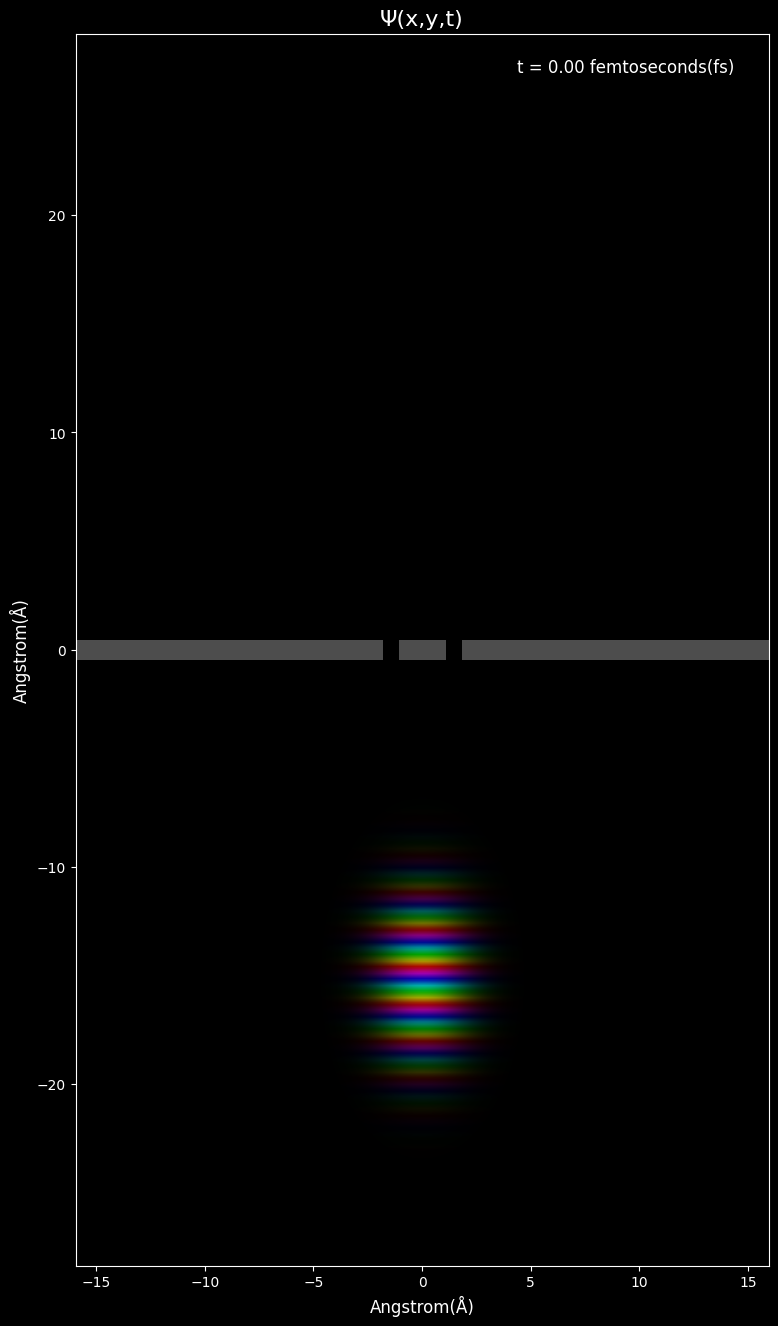

In [ ]:
import numpy as np
from qmsolve import Hamiltonian, SingleParticle, TimeSimulation, init_visualization, femtoseconds, m_e, Å
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
import matplotlib.colors as colors

#=========================================================================================================#
# Define global variables
#=========================================================================================================#

SLIT_SEPARATION = 2.0 * Å  # Separation between slits
SLIT_WIDTH = 0.7 * Å  # Width of the slits (increased from 0.5 Å)
SLIT_DEPTH = 0.5 * Å  # Depth of the slits (default 0.5 Å)

INITIAL_WAVEFUNCTION_STD_DEV = 1.0 * Å  # Standard deviation of the initial wavefunction
INITIAL_VELOCITY = 80 * Å / femtoseconds  # Initial velocity
TOTAL_SIMULATION_TIME = 0.7 * femtoseconds  # Total simulation time
DT = TOTAL_SIMULATION_TIME / 8000.  # Time step for the simulation
STORE_STEPS = 801  # Number of steps to store in the simulation

#=========================================================================================================#
# Define the Hamiltonian of a single particle
#=========================================================================================================#

# Interaction potential function defining a double slit
def double_slit(particle):
    return np.where(
        ((particle.x < -SLIT_SEPARATION/2 - SLIT_WIDTH) |
         (particle.x > SLIT_SEPARATION/2 + SLIT_WIDTH) |
         ((particle.x > -SLIT_SEPARATION/2) &
          (particle.x < SLIT_SEPARATION/2))) &
        ((particle.y < SLIT_DEPTH/2) & (particle.y > -SLIT_DEPTH/2)),
        1e5,
        0
    )

# Build the Hamiltonian of the system
H = Hamiltonian(particles=SingleParticle(m=m_e),
                potential=double_slit,
                spatial_ndim=2,
                N=512,  # Increased from 256
                extent=30 * Å)

#=========================================================================================================#
# Define the wavefunction at t = 0 (initial condition)
#=========================================================================================================#

def initial_wavefunction(particle):
    σ = INITIAL_WAVEFUNCTION_STD_DEV
    v0 = INITIAL_VELOCITY
    p_y0 = m_e * v0
    return (np.exp(-1/(4*σ**2) * ((particle.x - 0)**2 + (particle.y + 8 * Å)**2)) /
            np.sqrt(2 * np.pi * σ**2) * np.exp(p_y0 * particle.y * 1j))

#=========================================================================================================#
# Set and run the simulation
#=========================================================================================================#

sim = TimeSimulation(hamiltonian=H, method="split-step")
sim.run(initial_wavefunction, total_time=TOTAL_SIMULATION_TIME, dt=DT, store_steps=STORE_STEPS)

#=========================================================================================================#
# Visualize the time-dependent simulation and save the animation
#=========================================================================================================#

# Create a function to convert complex numbers to RGBA
def complex_to_rgba(z, max_val=None):
    if max_val is None:
        max_val = np.abs(z).max()

    hsv = np.zeros(z.shape + (3,))
    hsv[..., 0] = np.angle(z) / (2 * np.pi) + 0.5
    hsv[..., 1] = 1
    hsv[..., 2] = np.minimum(np.abs(z) / max_val, 1.0)

    return colors.hsv_to_rgb(hsv)

# Adjust figure size for Instagram Reel (16:9 aspect ratio)
fig, ax = plt.subplots(figsize=(9, 16), facecolor='black')
ax.set_xlim([-8.4375 * Å, 8.4375 * Å])  # Adjusted to maintain aspect ratio
ax.set_ylim([-15 * Å, 15 * Å])
ax.set_facecolor('black')
ax.spines['top'].set_color('white')
ax.spines['bottom'].set_color('white')
ax.spines['left'].set_color('white')
ax.spines['right'].set_color('white')
ax.xaxis.label.set_color('white')
ax.yaxis.label.set_color('white')
ax.tick_params(axis='x', colors='white')
ax.tick_params(axis='y', colors='white')

# ax.set_title("Double Slit Experiment\nQuantum Simulation", color='white', fontsize=16)
ax.set_title(f"Ψ(x,y,t)", color='white', fontsize=16)
ax.set_xlabel("Angstrom(Å)", color='white', fontsize=12)
ax.set_ylabel("Angstrom(Å)", color='white', fontsize=12)

# Get the potential grid
Vgrid = sim.H.Vgrid
Vmin, Vmax = np.min(Vgrid), np.max(Vgrid)

# Create a function to plot a single frame
def plot_frame(frame):
    ax.clear()

    # Plot the potential with increased contrast
    potential_plot = np.log(Vgrid - Vmin + 1)  # Add 1 to avoid log(0)
    ax.imshow(potential_plot, cmap="gray", origin="lower",
              interpolation="nearest", extent=[-8.4375*Å, 8.4375*Å, -15*Å, 15*Å])

    # Get the wavefunction at the current frame
    wf = sim.Ψ[frame]

    # Plot the wavefunction
    ax.imshow(complex_to_rgba(wf), origin="lower", interpolation="bilinear",
              extent=[-8.4375*Å, 8.4375*Å, -15*Å, 15*Å], alpha=0.7)

    t = frame * sim.dt
    # ax.set_title("Double Slit Experiment\nQuantum Simulation", color='white', fontsize=16)
    ax.set_title(f"Ψ(x,y,t)", color='white', fontsize=16)
    ax.set_xlabel("Angstrom(Å)", color='white', fontsize=12)
    ax.set_ylabel("Angstrom(Å)", color='white', fontsize=12)
    ax.text(0.95, 0.98, f"t = {t:.2f} femtoseconds(fs)", color='white', fontsize=12, ha='right', va='top', transform=ax.transAxes)
    ax.set_facecolor('black')
    ax.spines['top'].set_color('white')
    ax.spines['bottom'].set_color('white')
    ax.spines['left'].set_color('white')
    ax.spines['right'].set_color('white')
    ax.xaxis.label.set_color('white')
    ax.yaxis.label.set_color('white')
    ax.tick_params(axis='x', colors='white')
    ax.tick_params(axis='y', colors='white')
    ax.set_xlim([-8.4375 * Å, 8.4375 * Å])
    ax.set_ylim([-15 * Å, 15 * Å])
def update(frame):
    plot_frame(frame)

print(f"STORE_STEPS: {STORE_STEPS}")
print(f"Number of stored wavefunctions: {len(sim.Ψ)}")

num_frames = len(sim.Ψ)

ani = FuncAnimation(fig, update, frames=range(num_frames), repeat=False)

# Save the animation with 16:9 aspect ratio
ani.save("double_slit_simulation_reel.mp4", writer="ffmpeg", fps=30, dpi=300)